In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.trajectory.inspiral import EMRIInspiral
from multispline.spline import CubicSpline
import os

# Some elliptic functions for evaluating geodesic frequencies
from few.utils.elliptic import EllipK, EllipE, EllipPi

# base classes
from few.trajectory.ode.base import ODEBase

from typing import Union, Optional

from few.utils.utility import get_fundamental_frequencies, get_separatrix, ELQ_to_pex

In [2]:
# this class defines the right-hand side of the ODE
# we define the method "evaluate_rhs" according to our derivatives
# we set the "equatorial" and "background" properties accordingly
# we also set the "flux_output_convention" property to "pex" to tell the trajectory module what
# the RHS derivatives correspond to
class Schwarzschild_Plunge(ODEBase):
    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    def cache_values_and_check_bounds(self,y):
        return True

    @property
    def inspiral_type(self):
        return 'plunge'

    # @property
    # def flux_output_convention(self):
    #     return "pex"

    def evaluate_rhs(self, y):
        # guard against bad integration steps
        p, e, xI = y[:3]

        pdot = (-1/(2**(3./2.))*(6/p-1)**(3./2.)*(1-2/p))/(m2/m1)
        edot = 0
        xIdot = 0
        Phi_phi_dot = np.sqrt(3./2.)*3/p**2*(1-2/p)
        Phi_theta_dot = 0
        Phi_r_dot = 0

        dydt = [pdot, edot, xIdot, Phi_phi_dot, Phi_theta_dot, Phi_r_dot]

        return dydt

In [3]:
m1 = 1e6
m2 = 1e5
e0 = 0.0
x0 = 1.0

p0plunge = 5.5

Tplunge = 0.0002

inspPlunge = EMRIInspiral(func=Schwarzschild_Plunge)

trajPlunge = inspPlunge(m1, m2, 0.0, p0plunge, e0, x0, T=Tplunge, dt=1.0, upsample=True)

In [4]:
t,p,e,x,Phi_phi,Phi_theta,Phi_r = trajPlunge

(0.0, 600.0)

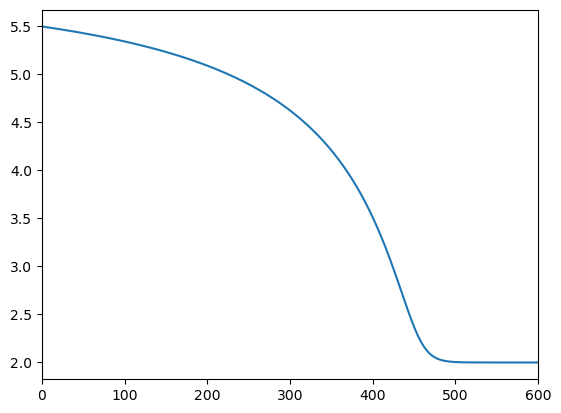

In [5]:
plt.plot(t,p)
plt.xlim(0,600)

In [6]:
data = np.loadtxt(os.getcwd() + "/data/plungeAmps-l2m2.dat")

In [7]:
ReAmpl2m2 = CubicSpline(data[:,0], data[:,1])
ImAmpl2m2 = CubicSpline(data[:,0], data[:,2])

In [8]:
def rs(r):
    return r + 2*np.log(r-2)

In [9]:
wavPlunge = (ReAmpl2m2(rs(p)) + 1j* ImAmpl2m2(rs(p)))*np.exp(-2j*Phi_phi)

/var/folders/pp/8lrdldlx72vbsqswqgflv0gm0000gn/T/ipykernel_65463/484005536.py:2: RuntimeWarning: divide by zero encountered in log
  return r + 2*np.log(r-2)
/var/folders/pp/8lrdldlx72vbsqswqgflv0gm0000gn/T/ipykernel_65463/484005536.py:2: RuntimeWarning: invalid value encountered in log
  return r + 2*np.log(r-2)
/var/folders/pp/8lrdldlx72vbsqswqgflv0gm0000gn/T/ipykernel_65463/2862242531.py:1: RuntimeWarning: invalid value encountered in multiply
  wavPlunge = (ReAmpl2m2(rs(p)) + 1j* ImAmpl2m2(rs(p)))*np.exp(-2j*Phi_phi)


(-0.75, 0.75)

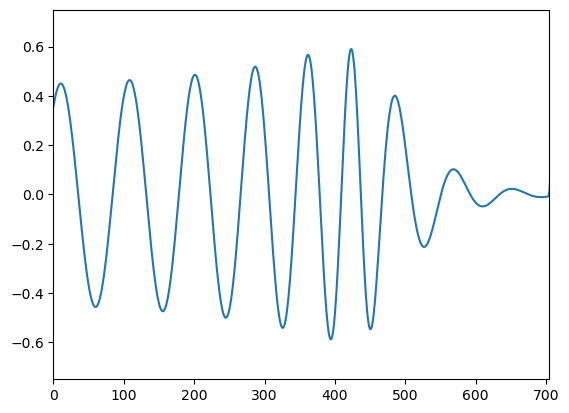

In [10]:
plt.plot(t,np.real(wavPlunge))
plt.xlim(0,705)
plt.ylim(-0.75,0.75)

In [14]:
# define trajectory RHS class
class SchwarzCirc1PA(ODEBase):
    """
    Schwarzschild circular flux ODE.
    Args:
        use_ELQ: If True, the ODE will output derivatives of the orbital elements of (E, L, Q). Defaults to False.
    """

    def __init__(self, *args, use_ELQ: bool = False, **kwargs):
        super().__init__(*args, use_ELQ=use_ELQ, **kwargs)

        data = np.loadtxt(os.getcwd() + "/data/QuasiCircularData_new.dat")
        
        x = np.unique(data[:, 0])

        self.pdot_interp_0pa =  CubicSpline(x, data[:, 1])
        self.pdot_interp_1pa =  CubicSpline(x, data[:, 2])

    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    @property
    def separatrix_buffer_dist(self):
        return 0.1

    @property
    def supports_ELQ(self):
        return False

    # @property
    # def flux_output_convention(self):
    #     return "pex"

    @property
    def inspiral_type(self):
        return 'inspiral'

    def distance_to_outer_boundary(self, y):
        p, e, x = self.get_pex(y)
        dist_p = 3.817 - np.log((p - 2. * e - 2.1))
        dist_e = 0.75 - e

        if dist_p < 0 or dist_e < 0:
            mult = -1
        else:
            mult = 1

        dist = mult * min(abs(dist_p), abs(dist_e))
        return dist

    def interpolate_flux_grids(
              self, p: float
              ) -> tuple[float]:

        if p < 6.25 or p > 30.: 
            raise ValueError("Interpolation: p out of bounds.")

        f0PA0PN = - 64./(5*(p**3))
        f1PA0PN = 176./(5*(p**4))

        pdot_0pa = (self.pdot_interp_0pa(p)/(p**4))+f0PA0PN
        if self.additional_args[0] != 1 and self.additional_args[0] != 0 :  #setting 1pa or 0pa
            raise ValueError("args for 1PA must be either 0 (for 0PA) or 1 (for 1PA)")
        pdot_1pa = self.additional_args[0]*(((self.pdot_interp_1pa(p))/(p**5))+f1PA0PN)
        return [pdot_0pa, pdot_1pa]

    def evaluate_rhs(self, y: Union[list[float], np.ndarray]) -> list[Union[float, np.ndarray]]:
        if self.use_ELQ:
            E, L, Q = y[:3]
            p, e, x = ELQ_to_pex(self.a, E, L, Q)

        else:
            p, e, x = y[:3]
            
        #eps=m2/m1
        eps = self.epsilon
        nu = eps/((1+eps)**2)
        Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(self.a, p, e, x)
        pdot_0pa, pdot_1pa = self.interpolate_flux_grids(p)
         
        pdot  = (nu/eps)*(pdot_0pa+(nu*pdot_1pa))
        return [pdot, 0., 0., Omega_phi, Omega_theta, Omega_r]

In [15]:
p0insp = 10
Tinsp = 0.0002

insp1PA = EMRIInspiral(func=SchwarzCirc1PA)

traj1PA = insp1PA(m1, m2, 0.0, p0insp, e0, x0, T=Tinsp, dt=10.0)

In [16]:
t1PA,p1PA,e1PA,x1PA,Phi_phi1PA,Phi_theta1PA,Phi_r1PA = traj1PA

In [19]:
t1PA[-1]

np.float64(5354.057108696644)

(0.0, 6500.0)

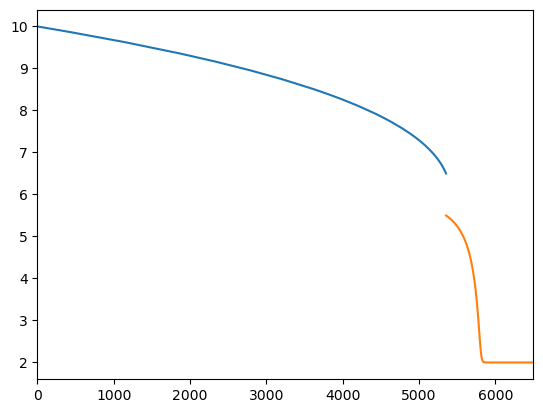

In [24]:
plt.plot(t1PA,p1PA)
plt.plot(t+t1PA[-1],p)
plt.xlim(0,6500)